<a href="https://colab.research.google.com/github/Lelytameyda29rpl/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D. TUGAS PRAKTIKUM**

**1. Import folder yang ada di Drive Anda.**

In [1]:
from google.colab import drive

# Accessing My Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Import beberapa library berikut yang akan digunakan selama uji coba praktikum minggu ke-6 berikut.**

In [4]:
import cv2 as cv                  # Mengimpor pustaka OpenCV (Open Source Computer Vision Library) untuk operasi pengolahan citra dan visi komputer. [cite: 1]
from google.colab.patches import cv2_imshow  # Mengimpor fungsi khusus untuk menampilkan citra OpenCV di lingkungan Google Colaboratory.
from skimage import io            # Mengimpor modul input/output (io) dari pustaka Scikit-image (skimage) yang digunakan untuk membaca, menulis, dan memanipulasi citra.
import matplotlib.pyplot as plt   # Mengimpor modul plotting (pyplot) dari Matplotlib untuk membuat grafik, kurva, dan menampilkan citra dengan sumbu koordinat.
import numpy as np                # Mengimpor pustaka NumPy untuk operasi matematika pada array multidimensi (seperti citra) secara efisien. [cite: 77]
import math                       # Mengimpor pustaka Math untuk fungsi matematika dasar (seperti akar kuadrat atau logaritma), meskipun NumPy sering lebih diutamakan untuk array.
import os                         # Mengimpor pustaka OS (Operating System) untuk berinteraksi dengan sistem operasi, seperti mengakses jalur file.
import glob                       # Mengimpor pustaka Glob untuk menemukan jalur file yang cocok dengan pola tertentu (misalnya, membaca semua file *.jpg dalam satu folder). [cite: 173]

**3. Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg)**

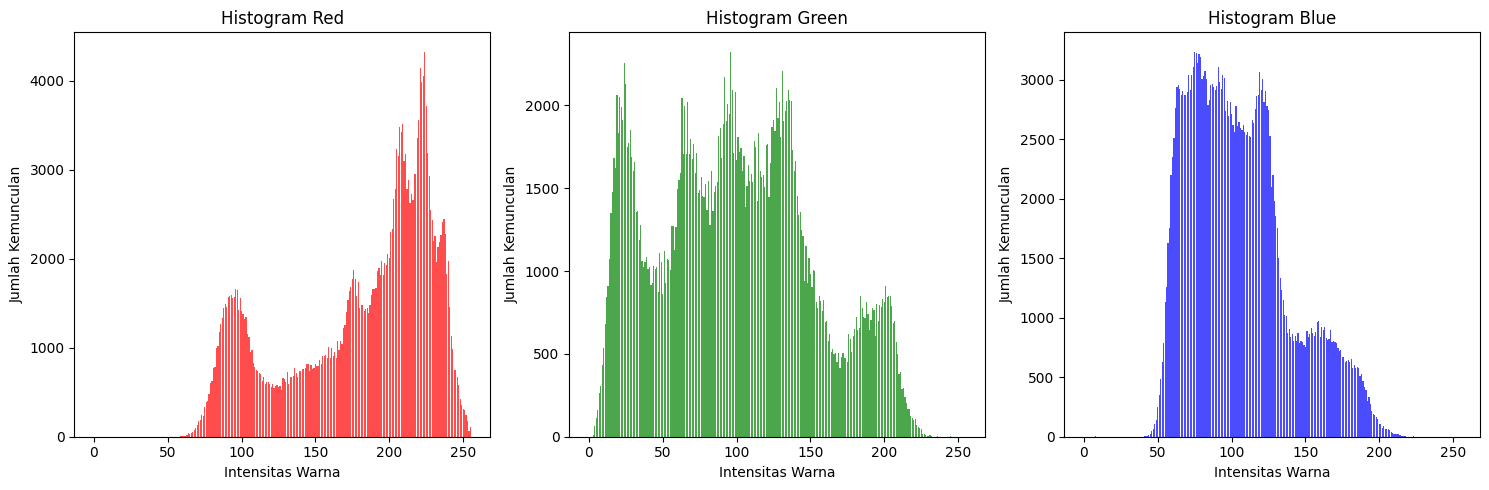

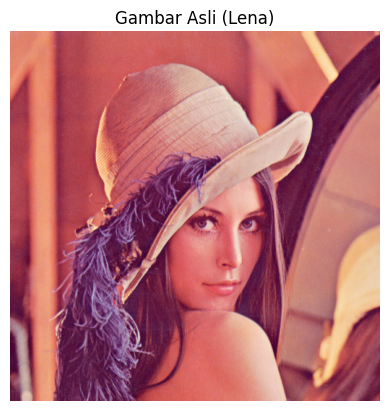

In [5]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# Inisialisasi array untuk menyimpan jumlah kemunculan setiap intensitas (0-255) untuk setiap channel
hist_r = [0] * 256
hist_g = [0] * 256
hist_b = [0] * 256

# Loop melalui setiap pixel
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r[r] += 1
        hist_g[g] += 1
        hist_b[b] += 1

# Plot histogram untuk masing-masing channel R, G, B
plt.figure(figsize=(15, 5))

# Channel Red
plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r, color='red', alpha=0.7)
plt.title('Histogram Red')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Green
plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g, color='green', alpha=0.7)
plt.title('Histogram Green')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Blue
plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b, color='blue', alpha=0.7)
plt.title('Histogram Blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Tampilkan gambar asli
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Gambar Asli (Lena)')
plt.show()

**Penjelasan Histogram**

**1. Histogram Red (Merah)**

- Terlihat dua puncak besar:

  - Puncak di intensitas sekitar 100–150, menandakan adanya banyak area berwarna merah sedang (seperti warna kulit Lena).

  - Puncak lain di intensitas 200–230, ini biasanya muncul di highlight (area terang, misalnya topi atau background).

  - Artinya, channel merah cukup dominan dalam citra ini.

**2. Histogram Green (Hijau)**

- Distribusinya lebih rata dan menyebar dari intensitas rendah sampai tinggi.

- Puncak paling banyak berada di intensitas 50–150, menandakan banyak warna hijau redup hingga sedang (muncul di area kulit dan background).

- Tidak setinggi channel merah, tetapi lebih merata.

**3. Histogram Blue (Biru)**

- Dominan di intensitas 50–150, artinya banyak bagian citra yang punya nilai biru menengah.

- Puncaknya tidak setinggi merah, tapi tetap signifikan karena background Lena (yang agak kebiruan).

- Bagian highlight (200–255) jumlahnya sedikit.

**Hubungan dengan Gambar Asli (Lena):**

- Wajah Lena (warna kulit) menghasilkan banyak intensitas merah → terlihat jelas di histogram Red.

- Background (biru-ungu) memunculkan distribusi pada channel Blue.

- Green muncul cukup banyak, karena gambar natural biasanya punya distribusi hijau yang cukup seimbang.

**Kesimpulan:**

- Citra Lena memiliki distribusi warna yang tidak rata di tiap channel.

- Channel Red paling dominan (karena warna kulit).

- Channel Blue signifikan karena background.

- Channel Green cukup merata, menjadi penyeimbang warna citra.

**4. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?**

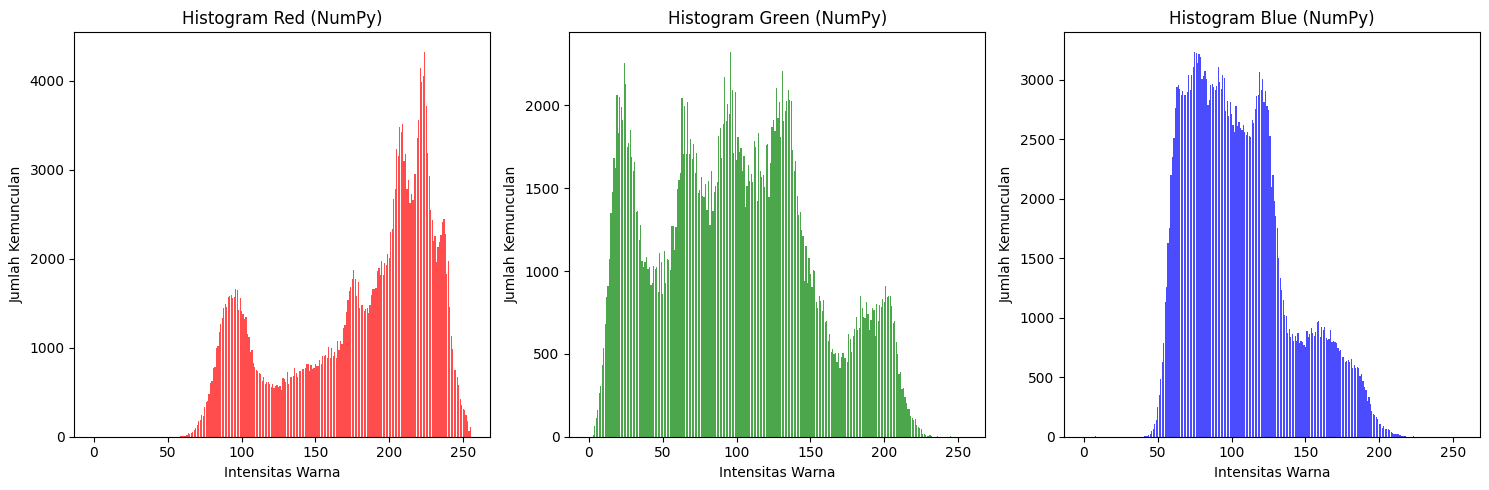

PERBANDINGAN HASIL MANUAL vs NUMPY:
Channel Red - Sama: True
Channel Green - Sama: True
Channel Blue - Sama: True

✅ SEMUA CHANNEL MENGHASILKAN HISTOGRAM YANG SAMA!


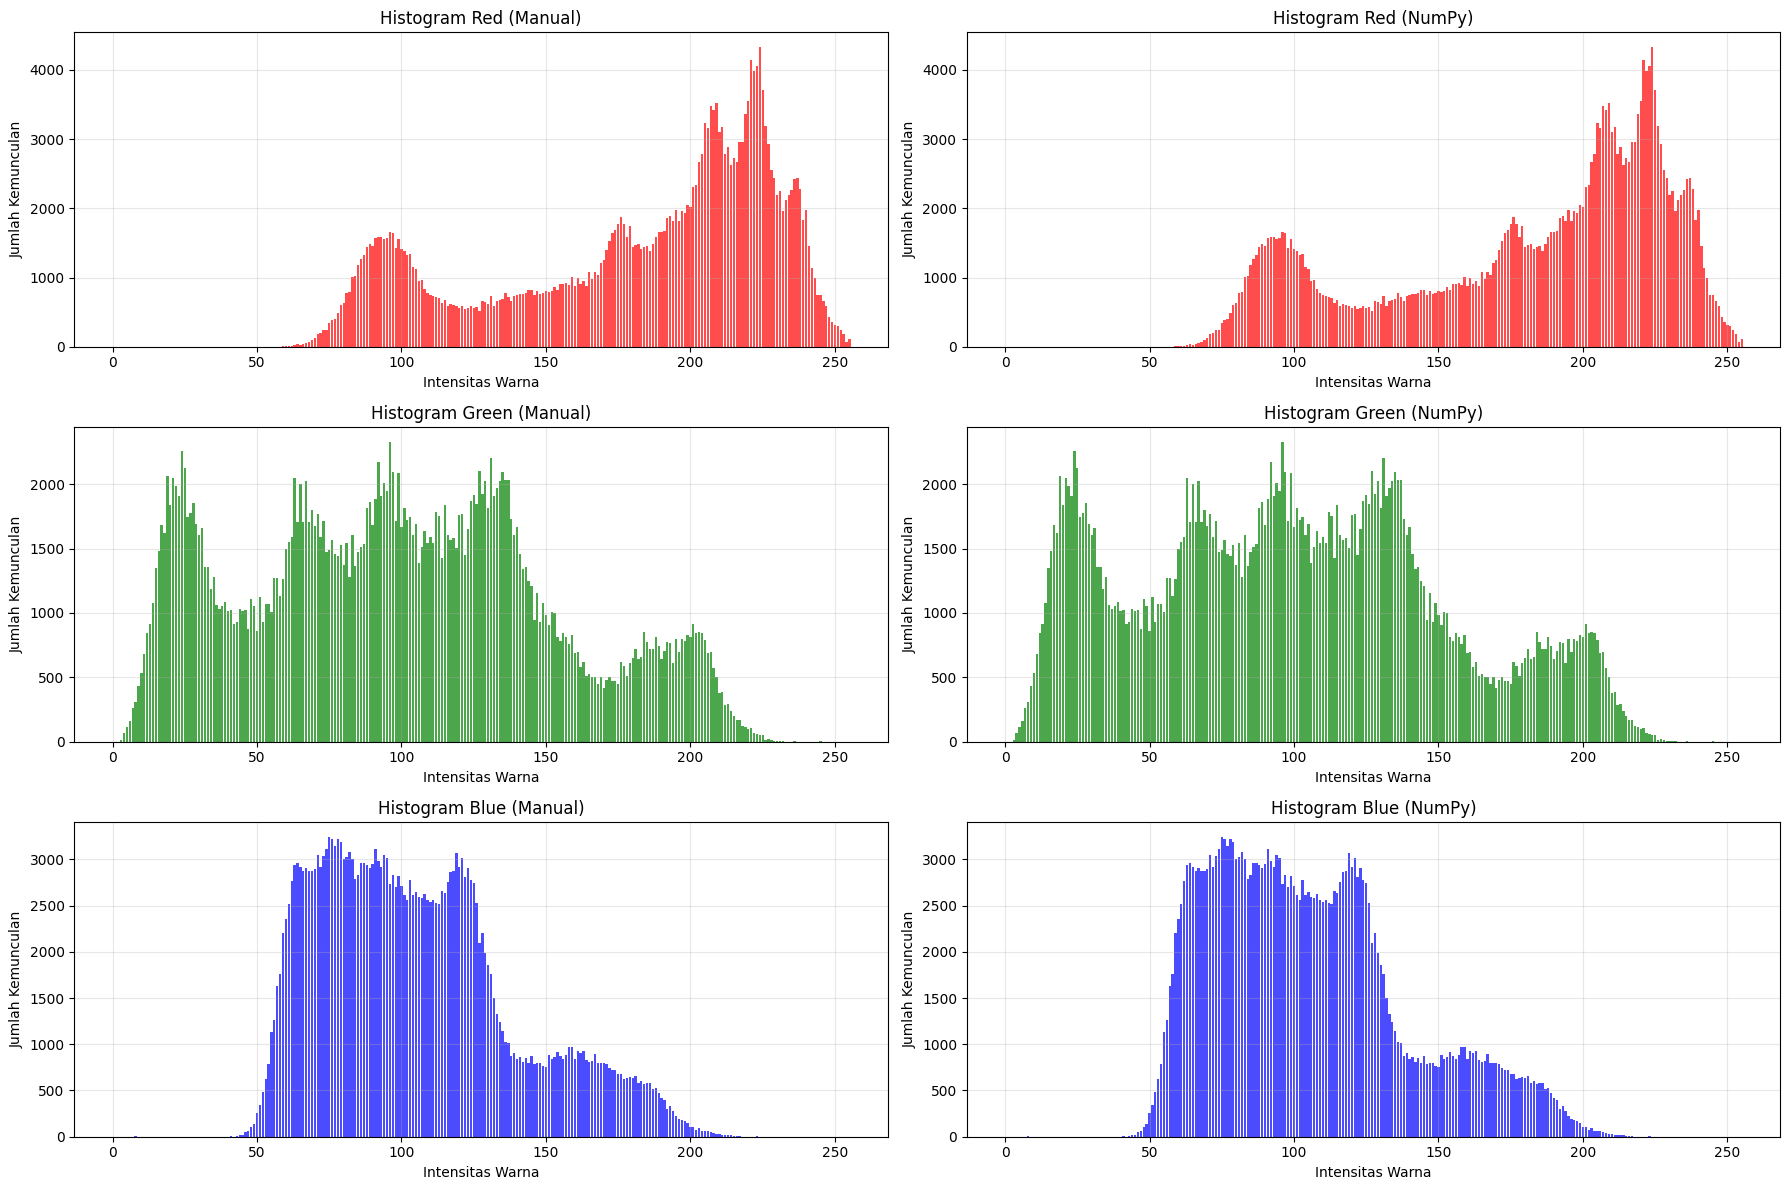

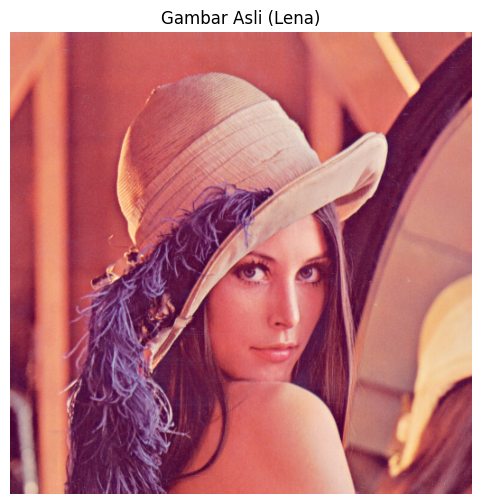

In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Membaca gambar lena.jpg
img = cv.imread('/content/drive/MyDrive/PCVK/JS5/Images/lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi BGR ke RGB

# Menggunakan np.histogram untuk menghitung histogram
hist_r_np, bins_r = np.histogram(img_rgb[:,:,0].flatten(), bins=256, range=[0,256])
hist_g_np, bins_g = np.histogram(img_rgb[:,:,1].flatten(), bins=256, range=[0,256])
hist_b_np, bins_b = np.histogram(img_rgb[:,:,2].flatten(), bins=256, range=[0,256])

# Plot histogram dari NumPy
plt.figure(figsize=(15, 5))

# Channel Red
plt.subplot(1, 3, 1)
plt.bar(range(256), hist_r_np, color='red', alpha=0.7)
plt.title('Histogram Red (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Green
plt.subplot(1, 3, 2)
plt.bar(range(256), hist_g_np, color='green', alpha=0.7)
plt.title('Histogram Green (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

# Channel Blue
plt.subplot(1, 3, 3)
plt.bar(range(256), hist_b_np, color='blue', alpha=0.7)
plt.title('Histogram Blue (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Hitung histogram manual untuk perbandingan
hist_r_manual = [0] * 256
hist_g_manual = [0] * 256
hist_b_manual = [0] * 256

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        r, g, b = img_rgb[i, j]
        hist_r_manual[r] += 1
        hist_g_manual[g] += 1
        hist_b_manual[b] += 1

# Konversi ke numpy array untuk perbandingan
hist_r_manual = np.array(hist_r_manual)
hist_g_manual = np.array(hist_g_manual)
hist_b_manual = np.array(hist_b_manual)

# Periksa apakah hasilnya sama
print("PERBANDINGAN HASIL MANUAL vs NUMPY:")
print("=" * 50)

# Channel Red
is_same_r = np.array_equal(hist_r_manual, hist_r_np)
print(f"Channel Red - Sama: {is_same_r}")

# Channel Green
is_same_g = np.array_equal(hist_g_manual, hist_g_np)
print(f"Channel Green - Sama: {is_same_g}")

# Channel Blue
is_same_b = np.array_equal(hist_b_manual, hist_b_np)
print(f"Channel Blue - Sama: {is_same_b}")

# Periksa perbedaan numerik (jika ada)
if not (is_same_r and is_same_g and is_same_b):
    print("\nPerbedaan detail:")
    for channel, manual, numpy, name in [('R', hist_r_manual, hist_r_np, 'Red'),
                                         ('G', hist_g_manual, hist_g_np, 'Green'),
                                         ('B', hist_b_manual, hist_b_np, 'Blue')]:
        diff_indices = np.where(manual != numpy)[0]
        if len(diff_indices) > 0:
            print(f"Channel {name}: {len(diff_indices)} perbedaan ditemukan")
            for idx in diff_indices[:5]:  # Tampilkan 5 perbedaan pertama
                print(f"  Intensitas {idx}: Manual={manual[idx]}, NumPy={numpy[idx]}")
else:
    print("\n✅ SEMUA CHANNEL MENGHASILKAN HISTOGRAM YANG SAMA!")

# Visualisasi perbandingan side-by-side untuk semua channel
plt.figure(figsize=(18, 12))

# Channel Red
plt.subplot(3, 2, 1)
plt.bar(range(256), hist_r_manual, color='red', alpha=0.7)
plt.title('Histogram Red (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 2)
plt.bar(range(256), hist_r_np, color='red', alpha=0.7)
plt.title('Histogram Red (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

# Channel Green
plt.subplot(3, 2, 3)
plt.bar(range(256), hist_g_manual, color='green', alpha=0.7)
plt.title('Histogram Green (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 4)
plt.bar(range(256), hist_g_np, color='green', alpha=0.7)
plt.title('Histogram Green (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

# Channel Blue
plt.subplot(3, 2, 5)
plt.bar(range(256), hist_b_manual, color='blue', alpha=0.7)
plt.title('Histogram Blue (Manual)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.subplot(3, 2, 6)
plt.bar(range(256), hist_b_np, color='blue', alpha=0.7)
plt.title('Histogram Blue (NumPy)')
plt.xlabel('Intensitas Warna')
plt.ylabel('Jumlah Kemunculan')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan gambar asli
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Gambar Asli (Lena)')
plt.show()

**Penjelasan:**

**1. Kedua metode menghasilkan hasil yang sama karena:**

- Keduanya menghitung frekuensi intensitas pixel dari 0-255

- Keduanya menggunakan range yang sama [0, 256]

- Keduanya menggunakan 256 bins (interval)

**2. Perbedaan implementasi:**

- Manual: Looping melalui setiap pixel dan increment counter

- NumPy: Menggunakan fungsi optimasi yang lebih cepat

**3. Keuntungan menggunakan NumPy:**

- Lebih cepat dan efisien

- Kode lebih singkat dan mudah dibaca

- Sudah teroptimasi untuk operasi array besar

**4. Keuntungan metode manual:**

- Memahami proses dasar pembuatan histogram

- Fleksibel untuk modifikasi algoritma

**Kesimpulan:**

- Kedua metode akan menghasilkan histogram yang identik karena melakukan perhitungan yang sama secara matematis. Perbedaan hanya pada cara implementasinya, dimana np.histogram lebih efisien dan direkomendasikan untuk penggunaan praktis.